# Partie 2 — Deep Learning Fondamental
## Jalon 7 : Comparaison ML vs Deep Learning
**Auteur : Hedi MATHLOUTHI**

In [1]:
import sys
sys.path.append('../src')

import pickle
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from dataset import ensure_dl_full_data, create_dataloaders
from models import EmotionCNN
from training import get_device, measure_inference_time
from utils import (
    EMOTIONS, plot_confusion_matrix, print_classification_report,
    plot_training_history, save_figure,
)

device = get_device()
print('Imports OK')

Imports OK


### 1. Résultats Baseline ML (Partie 1)

In [2]:
baseline_ml = {
    'Ridge (L2)': {'accuracy': 0.3027, 'time_sec': 0.1},
    'Lasso (L1)': {'accuracy': 0.3046, 'time_sec': 6.4},
    'ElasticNet': {'accuracy': 0.3046, 'time_sec': 7.0},
}
best_ml_name = 'Ridge (L2)'
best_ml_acc = baseline_ml[best_ml_name]['accuracy']
best_ml_time = baseline_ml[best_ml_name]['time_sec']
print(f'Baseline ML : {best_ml_name} — {best_ml_acc*100:.2f}% en {best_ml_time}s')

Baseline ML : Ridge (L2) — 30.27% en 0.1s


### 2. Résultats Deep Learning (Partie 2)

In [3]:
with open('../data/processed/opti_dl_results.pkl', 'rb') as f:
    dl_results = pickle.load(f)

with open('../data/processed/dl_initial_results.pkl', 'rb') as f:
    dl_init = pickle.load(f)

cnn_acc = dl_results['final_acc']
cnn_time = dl_results['final_time']
mlp_acc = dl_init['mlp_acc']
mlp_time = dl_init['mlp_time']

print(f'CNN optimisé : {cnn_acc*100:.2f}% en {cnn_time:.1f}s')
print(f'MLP (DL)     : {mlp_acc*100:.2f}% en {mlp_time:.1f}s')

CNN optimisé : 66.09% en 3602.0s
MLP (DL)     : 43.69% en 72.2s


### 3. Tableau comparatif

In [4]:
models_compare = {
    'Ridge ML (Partie 1)': {'acc': best_ml_acc, 'time': best_ml_time},
    'MLP DL': {'acc': mlp_acc, 'time': mlp_time},
    'CNN DL (optimisé)': {'acc': cnn_acc, 'time': cnn_time},
}

print('=' * 60)
print(f"{'Modèle':<25} {'Accuracy':>12} {'Temps (s)':>12}")
print('=' * 60)
for name, v in models_compare.items():
    print(f"{name:<25} {v['acc']*100:>11.2f}% {v['time']:>12.1f}")
print('=' * 60)
gain = (cnn_acc - best_ml_acc) * 100
print(f'\nGain CNN vs Ridge ML : +{gain:.2f} points d\'accuracy')

Modèle                        Accuracy    Temps (s)
Ridge ML (Partie 1)             30.27%          0.1
MLP DL                          43.69%         72.2
CNN DL (optimisé)               66.09%       3602.0

Gain CNN vs Ridge ML : +35.82 points d'accuracy


### 4. Visualisation comparative

Figure sauvegardée : figures/comparaison_ml_vs_dl.png


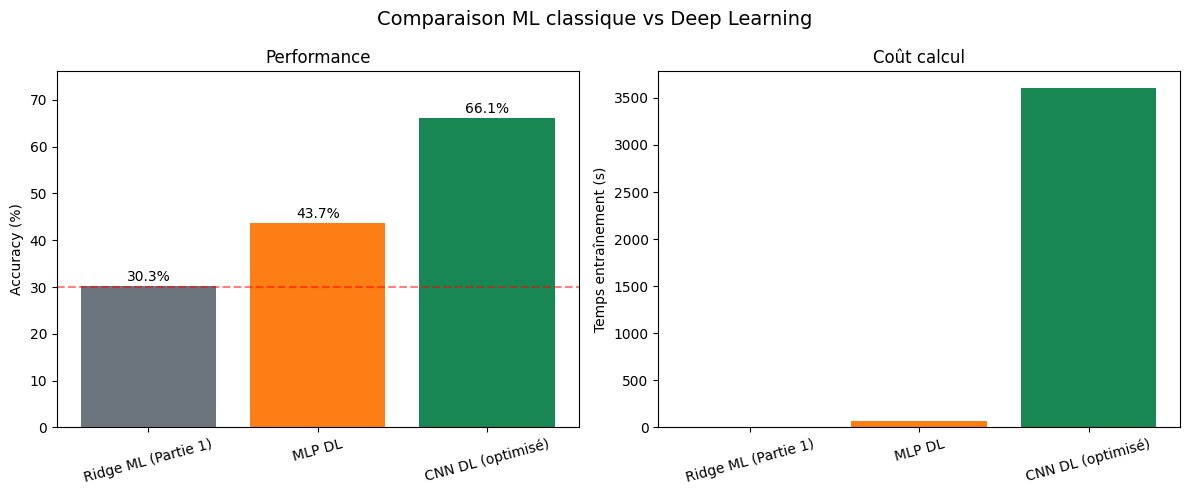

In [5]:
names = list(models_compare.keys())
accs = [models_compare[n]['acc'] * 100 for n in names]
times = [models_compare[n]['time'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#6c757d', '#fd7e14', '#198754']
axes[0].bar(names, accs, color=colors)
axes[0].axhline(30, color='red', linestyle='--', alpha=0.5, label='Baseline ML ~30%')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Performance')
axes[0].set_ylim(0, max(accs) + 10)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(names, times, color=colors)
axes[1].set_ylabel('Temps entraînement (s)')
axes[1].set_title('Coût calcul')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparaison ML classique vs Deep Learning', fontsize=14)
plt.tight_layout()
save_figure('comparaison_ml_vs_dl.png')
plt.show()

### 5. Matrice de confusion — CNN optimisé

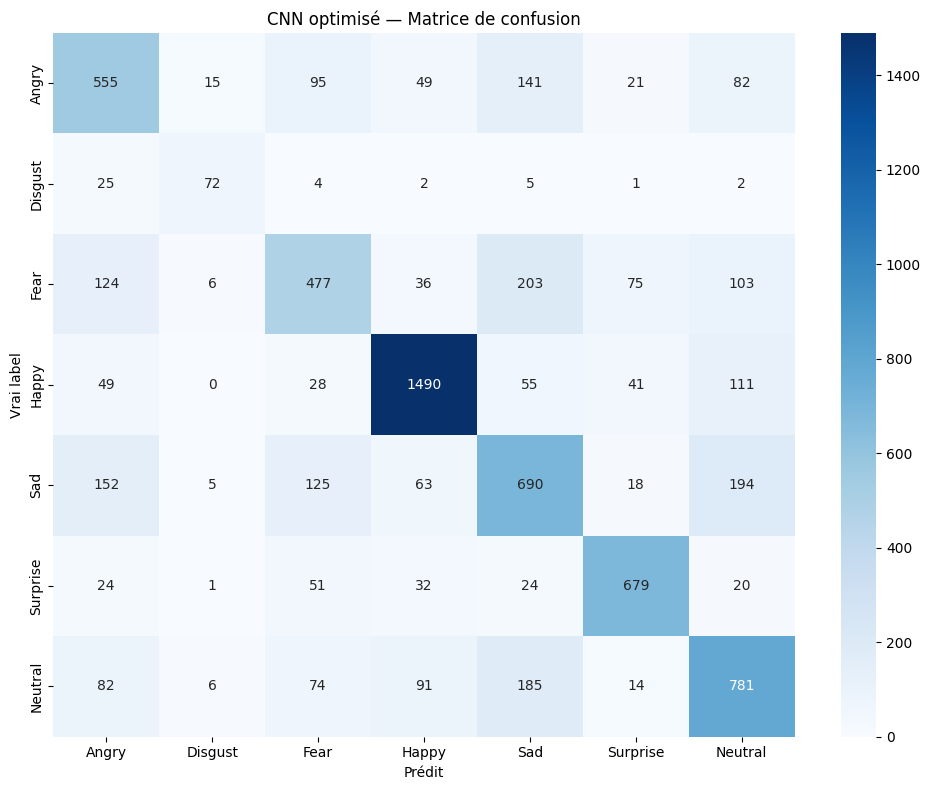

Figure sauvegardée : figures/confusion_matrix_cnn.png


<Figure size 640x480 with 0 Axes>

              precision    recall  f1-score   support

       Angry       0.55      0.58      0.56       958
     Disgust       0.69      0.65      0.67       111
        Fear       0.56      0.47      0.51      1024
       Happy       0.85      0.84      0.84      1774
         Sad       0.53      0.55      0.54      1247
    Surprise       0.80      0.82      0.81       831
     Neutral       0.60      0.63      0.62      1233

    accuracy                           0.66      7178
   macro avg       0.65      0.65      0.65      7178
weighted avg       0.66      0.66      0.66      7178



In [6]:
plot_confusion_matrix(
    dl_results['y_true'],
    dl_results['y_pred'],
    title='CNN optimisé — Matrice de confusion',
)
save_figure('confusion_matrix_cnn.png')
import matplotlib.pyplot as plt
plt.show()

print_classification_report(dl_results['y_true'], dl_results['y_pred'])

### 6. Temps d'inférence

In [7]:
data = ensure_dl_full_data('../data/processed/data_dl_full.pkl')
_, test_loader = create_dataloaders(data, batch_size=64, mode='image', augment_train=False)

cnn = EmotionCNN(dropout=float(dl_results['best_config']['dropout']))
cnn.load_state_dict(torch.load('../data/processed/cnn_best.pt', map_location=device))
cnn = cnn.to(device)

inf_time = measure_inference_time(cnn, test_loader, device)
print(f'Temps moyen par batch (inférence) : {inf_time*1000:.2f} ms')

Partie 2 : chargement ../data/processed/data_dl_full.pkl (28709 train)
Temps moyen par batch (inférence) : 46.81 ms


### 7. Analyse critique

In [8]:
print('=' * 60)
print('ANALYSE CRITIQUE — ML vs DEEP LEARNING')
print('=' * 60)
print()
print('1. PERFORMANCE')
print(f'   - ML (Ridge+PCA) : {best_ml_acc*100:.1f}% — ignore la spatialité')
print(f'   - MLP DL         : {mlp_acc*100:.1f}% — non-linéaire mais pixels aplatis')
print(f'   - CNN DL         : {cnn_acc*100:.1f}% — filtres = motifs faciaux locaux')
print()
print('2. LIMITES')
print('   - ML : underfitting, features peu discriminantes (PCA 100D)')
print('   - MLP : meilleur que Ridge mais perd la structure 2D')
print('   - CNN : plus lent à entraîner, nécessite GPU pour gros volumes')
print('   - Dataset déséquilibré : Disgust reste difficile pour tous')
print()
print('3. TEMPS DE CALCUL')
print(f'   - Ridge : {best_ml_time}s (quasi instantané)')
print(f'   - CNN   : {cnn_time:.1f}s (acceptable sur sous-échantillon)')
print('   - Trade-off : le CNN justifie son coût par le gain d\'accuracy')
print()
print('4. CONCLUSION')
print('   Le DL fondamental (CNN) dépasse la baseline ML.')
print('   La Partie 3 (Transfer Learning, dashboard) visera à')
print('   pousser encore les performances et l\'industrialisation.')
print('=' * 60)

ANALYSE CRITIQUE — ML vs DEEP LEARNING

1. PERFORMANCE
   - ML (Ridge+PCA) : 30.3% — ignore la spatialité
   - MLP DL         : 43.7% — non-linéaire mais pixels aplatis
   - CNN DL         : 66.1% — filtres = motifs faciaux locaux

2. LIMITES
   - ML : underfitting, features peu discriminantes (PCA 100D)
   - MLP : meilleur que Ridge mais perd la structure 2D
   - CNN : plus lent à entraîner, nécessite GPU pour gros volumes
   - Dataset déséquilibré : Disgust reste difficile pour tous

3. TEMPS DE CALCUL
   - Ridge : 0.1s (quasi instantané)
   - CNN   : 3602.0s (acceptable sur sous-échantillon)
   - Trade-off : le CNN justifie son coût par le gain d'accuracy

4. CONCLUSION
   Le DL fondamental (CNN) dépasse la baseline ML.
   La Partie 3 (Transfer Learning, dashboard) visera à
   pousser encore les performances et l'industrialisation.


### 8. Courbes d'entraînement du meilleur CNN

Figure sauvegardée : figures/cnn_optimized_training.png


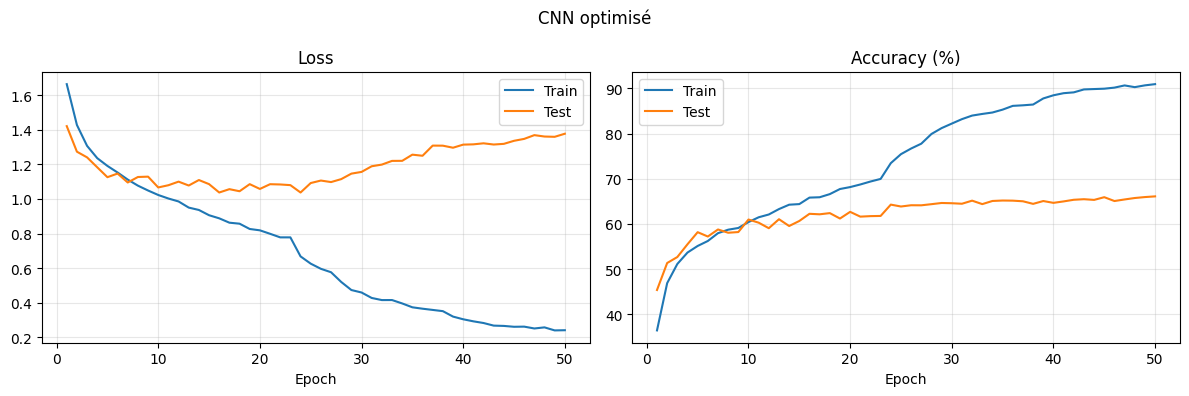

In [9]:
plot_training_history(dl_results['history'], 'CNN optimisé')
save_figure('cnn_optimized_training.png')
plt.show()